<a href="https://colab.research.google.com/github/Yoongishkarrr/week12_lab/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [2]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

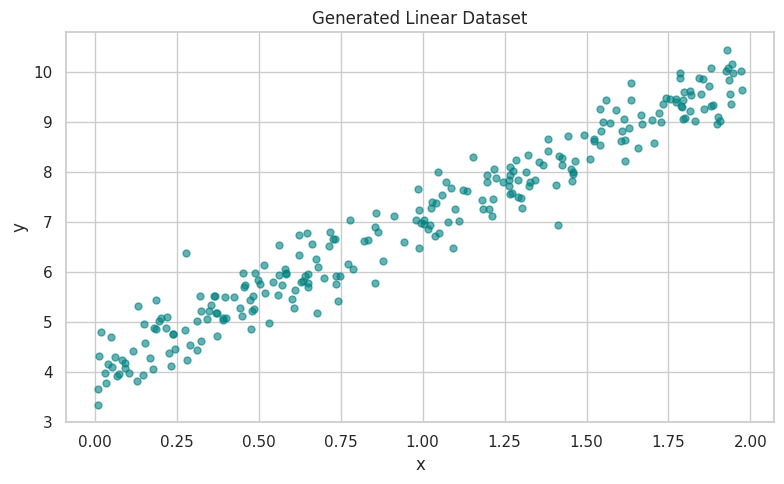

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.094780,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.322584,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.109276,"[4.054809763947758, 2.9712473416164924]"


In [3]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

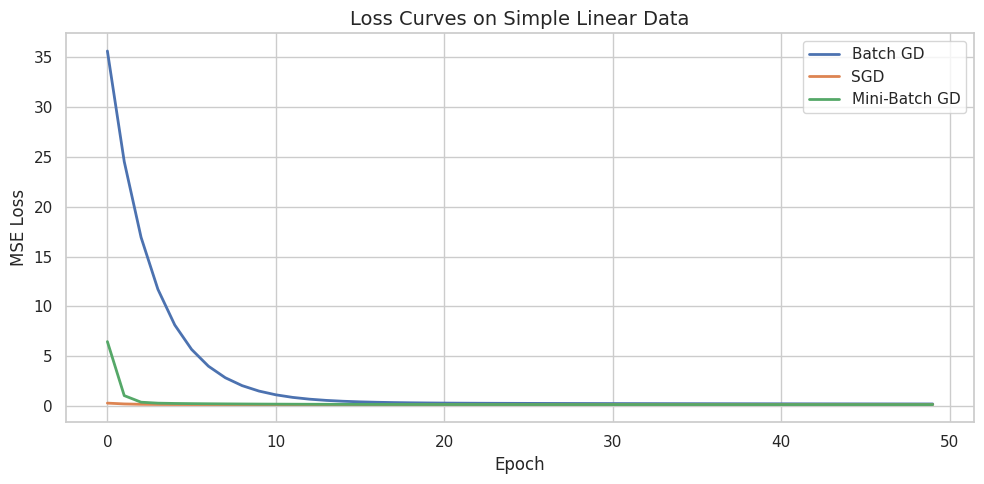

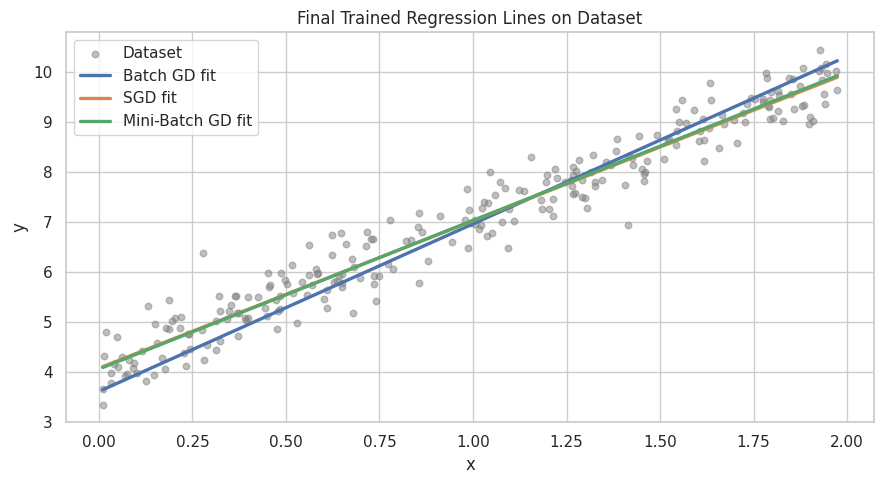

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.322584,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.109276,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.094780,"[3.606754282347466, 3.3500936172456846]"


In [4]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

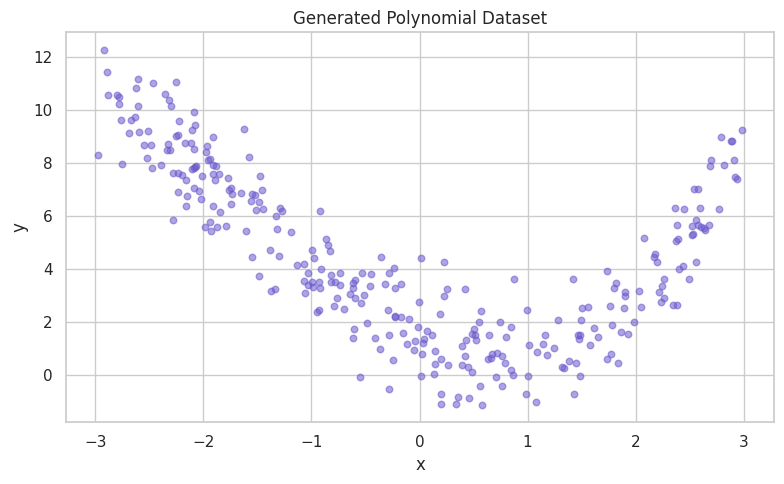

Polynomial data prepared.
Design matrix shape: (300, 4)


In [5]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [6]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.200829
1,SGD,1.292687,12,1.453795
2,Mini-Batch GD,1.292398,86,0.427222


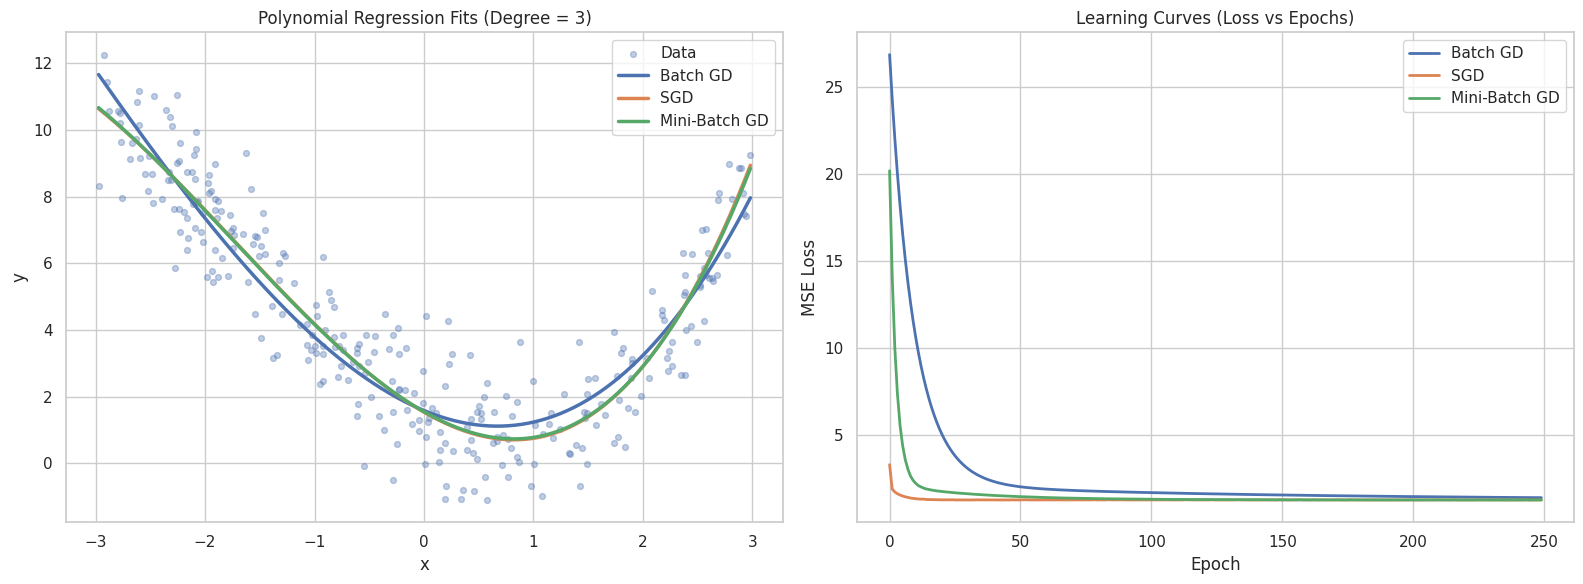

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.427222
1,SGD,1.292687,12,1.453795
0,Batch GD,1.424179,195,0.200829


In [7]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

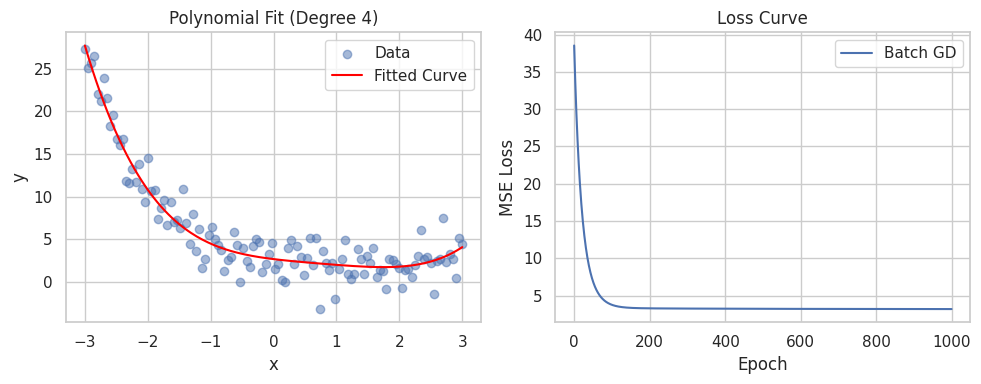

In [15]:
# -----------------------------
# Task 1 starter template
# -----------------------------
# TODO: Generate a new synthetic quadratic dataset with different coefficients/noise.
# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise

# x_t1 = ...
# y_t1 = ...

# TODO: Build degree-4 polynomial features and standardize using sklearn.

# TODO: Train Batch GD.

# TODO: Plot fitted curve and loss curve.
# (Reuse plotting style from tutorial.)

np.random.seed(42)

x_t1 = np.linspace(-3, 3, 120).reshape(-1, 1)

a, b, c, d, e = 2.5, -1.2, 0.9, -0.3, 0.05
noise = np.random.normal(0, 2, size=x_t1.shape)

y_t1 = a + b*x_t1 + c*x_t1**2 + d*x_t1**3 + e*x_t1**4 + noise

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(x_t1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

def batch_gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for i in range(n_iters):
        gradients = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradients

        loss = (1/m) * np.sum((X @ theta - y)**2)
        losses.append(loss)

    return theta, losses

theta, losses = batch_gradient_descent(X_b, y_t1, lr=0.05, n_iters=2000)

x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
X_plot_poly = poly.transform(x_plot)
X_plot_scaled = scaler.transform(X_plot_poly)
X_plot_b = np.c_[np.ones((X_plot_scaled.shape[0], 1)), X_plot_scaled]

y_pred = X_plot_b @ theta
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(x_t1, y_t1, alpha=0.5, label="Data")
plt.plot(x_plot, y_pred, color='red', label="Fitted Curve")
plt.title("Polynomial Fit (Degree 4)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses_t1, label="Batch GD")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

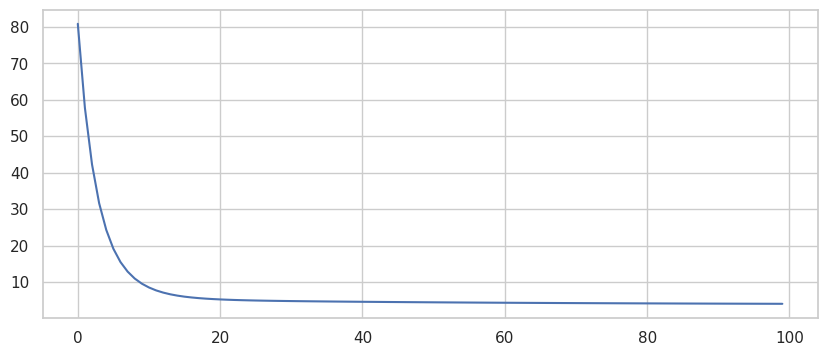

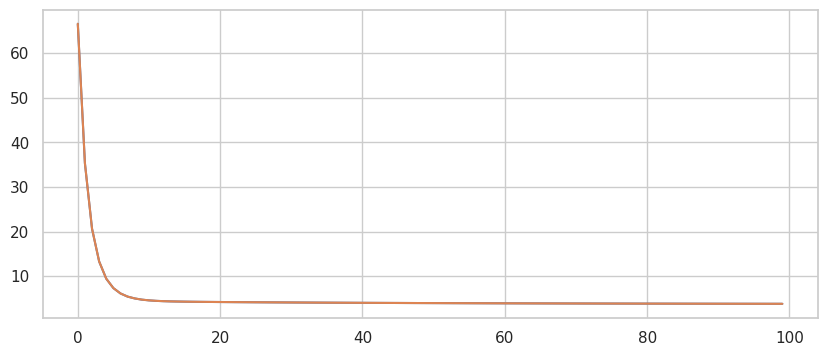

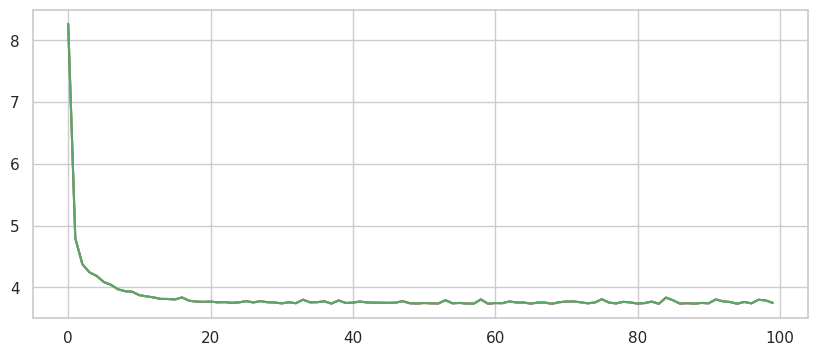

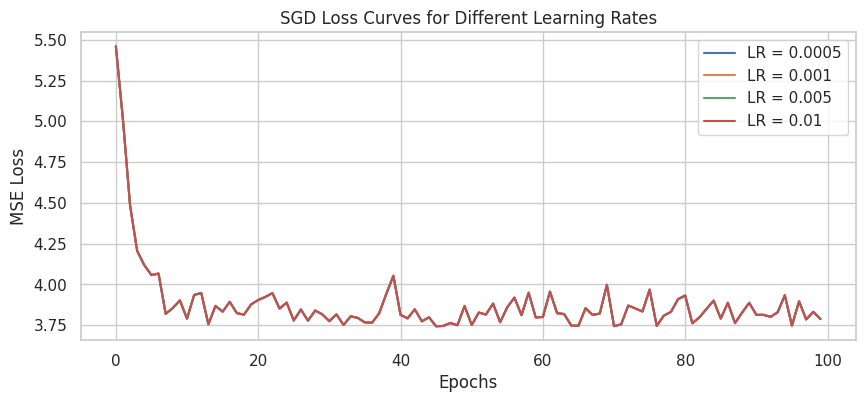

In [26]:
# -----------------------------
# Task 2 starter template
# -----------------------------

np.random.seed(0)

learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

x = np.linspace(-3, 3, 120).reshape(-1, 1)
noise = np.random.normal(0, 2, size=x.shape)

y = 1.5 - 0.8*x + 1.2*x**2 - 0.4*x**3 + 0.08*x**4 + noise

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(x)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

def stochastic_gradient_descent(X, y, lr=0.01, n_epochs=50):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            gradient = 2 * xi.T @ (xi @ theta - yi)
            theta -= lr * gradient

        loss = (1/m) * np.sum((X @ theta - y)**2)
        losses.append(loss)

    return theta, losses

for lr in learning_rates:
  _, losses = stochastic_gradient_descent(X_b, y, lr=lr, n_epochs=100)
  sgd_histories[lr] = losses

  plt.figure(figsize=(10, 4))
  for lr, history in sgd_histories.items():
    plt.plot(losses, label=f"LR = {lr}")

plt.title("SGD Loss Curves for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

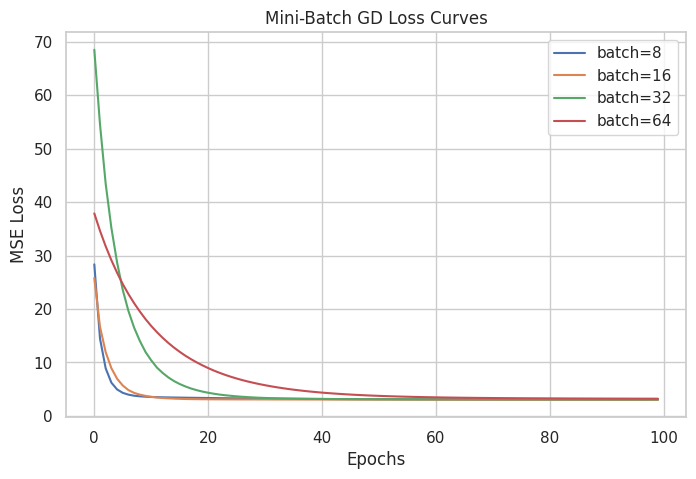

   Batch Size  Final MSE  Time (s)
0           8   3.031341  0.056569
1          16   3.018301  0.025548
2          32   3.072099  0.017266
3          64   3.215414  0.010968


In [36]:
# -----------------------------
# Task 3 starter template
# -----------------------------

np.random.seed(1)

batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

x = np.linspace(-3, 3, 120).reshape(-1, 1)
noise = np.random.normal(0, 2, size=x.shape)

y = 2.0 - 1.0*x + 0.7*x**2 - 0.2*x**3 + 0.05*x**4 + noise

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(x)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_t3 = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
y_t3 = y


class MiniBatchGD:
    def __init__(self, lr=0.01, epochs=100, batch_size=32):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.random.randn(n, 1)
        self.loss_history = []

        start_time = time.time()

        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, m, self.batch_size):
                xi = X_shuffled[i:i+self.batch_size]
                yi = y_shuffled[i:i+self.batch_size]

                gradients = (2/len(xi)) * xi.T @ (xi @ self.theta - yi)
                self.theta -= self.lr * gradients

            loss = (1/m) * np.sum((X @ self.theta - y)**2)
            self.loss_history.append(loss)

        self.training_time = time.time() - start_time

    def predict(self, X):
        return X @ self.theta


for bs in batch_sizes:
    model = MiniBatchGD(lr=0.01, epochs=100, batch_size=bs)
    model.fit(X_t3, y_t3)

    mbgd_histories[bs] = model.loss_history

    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": mean_squared_error(y_t3, model.predict(X_t3)),
        "Time (s)": model.training_time
    })


plt.figure(figsize=(8, 5))

for bs, losses in mbgd_histories.items():
    plt.plot(losses, label=f"batch={bs}")

plt.title("Mini-Batch GD Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()


df_metrics = pd.DataFrame(mbgd_metrics)
print(df_metrics)

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

          Method  Final MSE  Time (s)
0       Batch GD   3.917420  0.004206
1            SGD   3.937490  0.270801
2  Mini-Batch GD   3.931669  0.014121


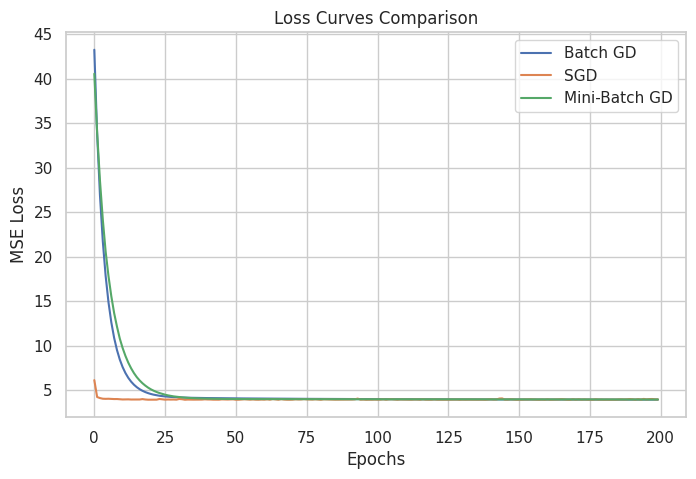

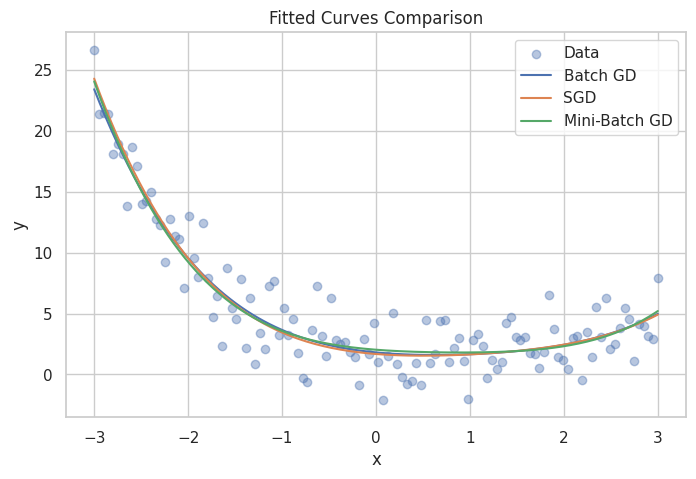

In [35]:
# -----------------------------
# Task 4 starter template
# -----------------------------
# TODO: Use one shared dataset and preprocessing.
# X_t4, y_t4 = ...

np.random.seed(7)

# 1. Shared dataset
x = np.linspace(-3, 3, 120).reshape(-1, 1)
noise = np.random.normal(0, 2, size=x.shape)

y = 1.8 - 0.9*x + 0.8*x**2 - 0.25*x**3 + 0.06*x**4 + noise

# Preprocessing
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(x)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_t4 = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
y_t4 = y


# 2. Unified Gradient Descent class
class GradientDescentRegressor:
    def __init__(self, method="batch", lr=0.01, epochs=100, batch_size=32):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.random.randn(n, 1)
        self.loss_history = []

        start = time.time()

        for epoch in range(self.epochs):

            if self.method == "batch":
                gradients = (2/m) * X.T @ (X @ self.theta - y)
                self.theta -= self.lr * gradients

            elif self.method == "sgd":
                indices = np.random.permutation(m)
                for i in indices:
                    xi = X[i:i+1]
                    yi = y[i:i+1]
                    gradients = 2 * xi.T @ (xi @ self.theta - yi)
                    self.theta -= self.lr * gradients

            elif self.method == "mini-batch":
                indices = np.random.permutation(m)
                X_sh = X[indices]
                y_sh = y[indices]

                for i in range(0, m, self.batch_size):
                    xi = X_sh[i:i+self.batch_size]
                    yi = y_sh[i:i+self.batch_size]
                    gradients = (2/len(xi)) * xi.T @ (xi @ self.theta - yi)
                    self.theta -= self.lr * gradients

            loss = (1/m) * np.sum((X @ self.theta - y)**2)
            self.loss_history.append(loss)

        self.training_time = time.time() - start

    def predict(self, X):
        return X @ self.theta


# 3. Models
task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=200),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=200),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.01, epochs=200, batch_size=32)
}

task4_rows = []
predictions = {}

# 4. Train & collect metrics
for name, model in task4_models.items():
    model.fit(X_t4, y_t4)
    y_pred = model.predict(X_t4)

    predictions[name] = y_pred

    task4_rows.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_t4, y_pred),
        "Time (s)": model.training_time
    })


# 5. Summary table
summary_df = pd.DataFrame(task4_rows)
print(summary_df)


# 6. Plot loss curves
plt.figure(figsize=(8, 5))
for name, model in task4_models.items():
    plt.plot(model.loss_history, label=name)

plt.title("Loss Curves Comparison")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


# 7. Plot fitted curves
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
X_plot_poly = poly.transform(x_plot)
X_plot_scaled = scaler.transform(X_plot_poly)
X_plot_b = np.c_[np.ones((X_plot_scaled.shape[0], 1)), X_plot_scaled]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, label="Data")

for name, model in task4_models.items():
    y_curve = model.predict(X_plot_b)
    plt.plot(x_plot, y_curve, label=name)

plt.title("Fitted Curves Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

_Write your response here..._

###  Bias–Variance Tradeoff (Polynomial Degree)

**Definition**

* Bias: Error due to overly simple model assumptions
* Variance: Error due to sensitivity to training data (noise)


###  Low Polynomial Degree (Underfitting)

* Model is too simple
* Cannot capture true relationship

**Effects:**

* High training error
* High test/validation error
* Curve is too smooth

 **High Bias, Low Variance**


###  High Polynomial Degree (Overfitting)

* Model is too complex
* Fits noise instead of actual pattern

**Effects:**

* Very low training error
* High test/validation error
* Curve becomes highly irregular (wiggly)

 **Low Bias, High Variance**


###  Optimal Polynomial Degree

* Balanced model complexity
* Captures true pattern without fitting noise

**Effects:**

* Low training error
* Low validation error
* Good generalization


###  Key Insight

* Increasing degree:

  * ↓ Bias
  * ↑ Variance

 Goal: Minimize **validation/test error**, not just training error


### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

_Write your response here..._

###  Variance in SGD vs Batch GD

**Why SGD has higher variance**

* **Stochastic Gradient Descent (SGD)** updates parameters using **one sample at a time**
* Each sample provides a **noisy estimate** of the true gradient

**Result:**

* Updates fluctuate heavily (zig-zag path)
* Loss curve is noisy
* Does not smoothly converge to minimum

 Gradient estimate ≈ high randomness → **high variance**


###  Batch Gradient Descent (BGD)

* Uses **entire dataset** to compute gradient
* Produces **accurate, stable gradient direction**

**Result:**

* Smooth and consistent updates
* Stable convergence
* But computationally expensive

 Gradient estimate ≈ true gradient → **low variance**


###  How Mini-Batch GD balances this

**Mini-Batch Gradient Descent**

* Uses a **small subset of data (batch)** instead of 1 sample or full dataset

**Key idea:**

* Average over a few samples → reduces noise
* Still faster than full batch

**Result:**

* Less noisy than SGD
* Faster and more efficient than Batch GD
* Smoother convergence but still some randomness


###  Summary

* **SGD** → Fast but noisy (high variance)
* **Batch GD** → Stable but slow (low variance)
* **Mini-Batch GD** → Trade-off between speed and stability

Mini-batch works best in practice because it balances **efficiency + convergence stability**


### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

_Write your response here..._

###  Importance of Feature Scaling in Polynomial Regression (Gradient Descent)

**Why scaling matters**

* Polynomial features (e.g., (x, x^2, x^3, x^4)) can have **vastly different magnitudes**
* Example: if (x = 10), then
  (x = 10,; x^2 = 100,; x^3 = 1000,; x^4 = 10000)

 This creates **imbalanced feature scales**


###  Problems without scaling

**1. Slow convergence**

* Gradient Descent struggles because one feature dominates updates
* Takes many iterations to reach minimum


**2. Zig-zag optimization path**

* Cost function becomes **elongated (ill-conditioned)**
* Updates oscillate instead of moving directly toward minimum


**3. Unstable training**

* Large feature values → large gradients
* Can cause:

  * Overshooting minimum
  * Divergence (loss increases instead of decreases)


**4. Learning rate sensitivity**

* Hard to choose a good learning rate
* Small LR → extremely slow
* Large LR → divergence

###  Benefits of scaling (e.g., Standardization)

* All features have similar scale (mean ≈ 0, std ≈ 1)
* Gradient Descent behaves more uniformly

**Results:**

* Faster convergence
* More stable updates
* Easier learning rate tuning
* Smoother loss curve


###  Key takeaway

Feature scaling is **essential** for polynomial regression with Gradient Descent
It transforms an inefficient, unstable optimization problem into a **fast and well-behaved one**


# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.